In [1]:
from pathlib import Path
import json

from hydra.utils import instantiate
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
import torch

from flatcfm.data.dataset import CondFMDataset
from flatcfm.models.flow import sample_ode


In [ ]:
experiment_name = "toy_fm_identity"
# experiment_name = "toy_ode_identity"

run_root = Path("artifacts/runs") / experiment_name
run_dirs = sorted(path for path in run_root.glob("*") if path.is_dir())
if not run_dirs:
    raise FileNotFoundError(f"No runs found under {run_root}")

run_dir = run_dirs[-1]

cfg = OmegaConf.load(run_dir / "run_config.yaml")
history = json.loads((run_dir / "history.json").read_text())
run_metadata = json.loads((run_dir / "run_metadata.json").read_text())
checkpoint_path = Path(run_metadata["checkpoint_path"])
if not checkpoint_path.is_absolute():
    checkpoint_path = (Path.cwd() / checkpoint_path).resolve()

run_dir, checkpoint_path

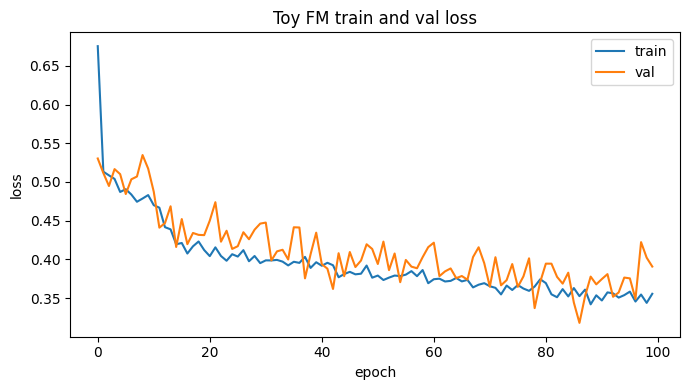

In [4]:
plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(f"Toy {str(cfg.task.name).upper()} train and val loss")
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
device


'mps'

In [6]:
datamodule = instantiate(
    cfg.data,
    data=OmegaConf.to_container(cfg.data, resolve=True),
    splitter=OmegaConf.to_container(cfg.splitter, resolve=True),
    space=OmegaConf.to_container(cfg.space, resolve=True),
    condition=OmegaConf.to_container(cfg.condition, resolve=True),
    paths=OmegaConf.to_container(cfg.paths, resolve=True),
    ae_geometry=OmegaConf.to_container(cfg.ae_geometry, resolve=True),
    task=OmegaConf.to_container(cfg.task, resolve=True),
    predict=OmegaConf.to_container(cfg.predict, resolve=True),
    trainer=OmegaConf.to_container(cfg.trainer, resolve=True),
    _recursive_=False,
)
datamodule.setup("fit")

model = instantiate(
    cfg.model,
    model_cfg=OmegaConf.to_container(cfg.model, resolve=True),
    task_cfg=OmegaConf.to_container(cfg.task, resolve=True),
    loss_cfg=OmegaConf.to_container(cfg.loss, resolve=True),
    predict_cfg=OmegaConf.to_container(cfg.predict, resolve=True),
    _recursive_=False,
    **datamodule.get_model_init_kwargs(),
)

checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["state_dict"])
model = model.to(device)
model.eval()
flow = model.model

full_adata = datamodule.adata_full
full_cond_batch = datamodule._build_condition_batch(full_adata)


In [7]:
ds = CondFMDataset(
    full_adata,
    full_cond_batch,
    control_col=datamodule.schema.control_column,
    control_value=datamodule.schema.control_value,
    use_pca=False,
    use_norm=False,
)

x_0 = ds.control_data.to(device)
n_samples = x_0.size(0)


In [8]:
cond_1 = {
    "perturbations": torch.full((n_samples,), 1, dtype=torch.long, device=device),
    "perturbation_covariates": {},
    "sample_covariates": {},
}
cond_2 = {
    "perturbations": torch.full((n_samples,), 2, dtype=torch.long, device=device),
    "perturbation_covariates": {},
    "sample_covariates": {},
}


In [9]:
with torch.no_grad():
    x_1 = sample_ode(flow, x_0, cond_1, time=1.0)
    x_2 = sample_ode(flow, x_0, cond_2, time=1.0)


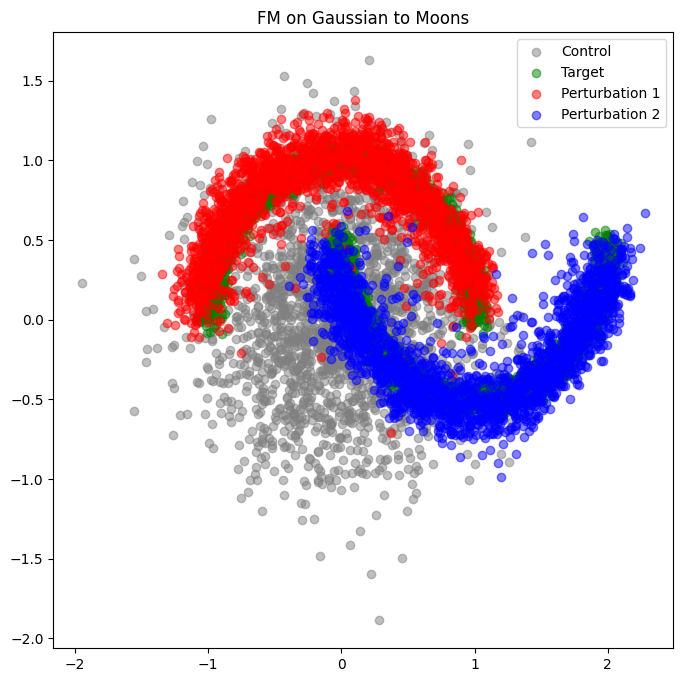

In [10]:
plt.figure(figsize=(8, 8))
plt.scatter(x_0[:, 0].cpu(), x_0[:, 1].cpu(), color="gray", alpha=0.5, label="Control")
plt.scatter(ds.perturbed_data[:, 0].cpu(), ds.perturbed_data[:, 1].cpu(), color="green", alpha=0.5, label="Target")
plt.scatter(x_1[:, 0].cpu(), x_1[:, 1].cpu(), color="red", alpha=0.5, label="Perturbation 1")
plt.scatter(x_2[:, 0].cpu(), x_2[:, 1].cpu(), color="blue", alpha=0.5, label="Perturbation 2")
plt.legend()
plt.title(f"{str(cfg.task.name).upper()} on Gaussian to Moons")
plt.show()